<a href="https://colab.research.google.com/github/0-SHINN/Data-Analysis/blob/main/Churn-Analysis/Code/churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get -qq -y install fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

from google.colab import drive
drive.mount('/content/drive')

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('/content/drive/MyDrive/customer_behavior_mart.csv', parse_dates=['first_join_date', 'first_order_date', 'last_order_date'])

df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   customer_id           100000 non-null  int64         
 1   gender                100000 non-null  object        
 2   age_group             100000 non-null  object        
 3   device_type           100000 non-null  object        
 4   first_join_date       100000 non-null  datetime64[ns]
 5   cohort_month          100000 non-null  object        
 6   first_order_date      50242 non-null   datetime64[ns]
 7   last_order_date       50242 non-null   datetime64[ns]
 8   days_active           50242 non-null   float64       
 9   total_orders          100000 non-null  int64         
 10  is_repeat_customer    100000 non-null  bool     

In [3]:
#활동 주차
df["weeks_active"] = (df["days_active"]) // 7

#이탈 여부 - 마지막 구매일이 2022년 7월 31일 기준 30일이상 차이 난다면 이탈
base_date = pd.to_datetime('2022-07-31')
churn_threshold = 30
df["is_churned"] = (base_date - df["last_order_date"]).dt.days > churn_threshold

In [4]:
### 1. Z-test 함수 정의
def run_z_test(df, column, metric):
    counts = df.groupby(column)[metric].sum()
    ns = df.groupby(column)[metric].count()
    stat, p = proportions_ztest(count=counts, nobs=ns)
    return f'=== {column} / {metric} ===\nZ-stat: {stat: .4f}, p-value: {p:.4f}\n'

### 2. Chi-square test 함수 정의
def run_chi_square(df, column, metric):
    contingency = pd.crosstab(df[column], df[metric])
    chi2, p, _, _ = chi2_contingency(contingency)
    return f'=== {column} / {metric} ===\nChi²: {chi2:.4f}, p-value: {p:.4f}\n'

### H1. 유저 속성별 이탈/재구매 차이 분석

In [5]:
# 이탈률 증가의 원인을 파악하기 위해 문제 상황 이전에 가입한 유저까지만 집계
df_filtered = df[df['first_join_date'] <= pd.to_datetime('2022-04-30')].copy()

for col in ['gender', 'age_group', 'device_type']:
    churn_rate = df_filtered.groupby(col)['is_churned'].mean()
    repeat_rate = df_filtered.groupby(col)['is_repeat_customer'].mean()
    print(f'=== {col} ===')
    print('이탈률:')
    print(churn_rate)
    print('재구매율:')
    print(repeat_rate)
    print()

=== gender ===
이탈률:
gender
F    0.424523
M    0.423877
Name: is_churned, dtype: float64
재구매율:
gender
F    0.428975
M    0.427261
Name: is_repeat_customer, dtype: float64

=== age_group ===
이탈률:
age_group
10대       0.422927
20대       0.422697
30대       0.426651
40대       0.424383
50대 이상    0.419283
Name: is_churned, dtype: float64
재구매율:
age_group
10대       0.430699
20대       0.428539
30대       0.427081
40대       0.431178
50대 이상    0.428251
Name: is_repeat_customer, dtype: float64

=== device_type ===
이탈률:
device_type
Android    0.424891
iOS        0.422329
Name: is_churned, dtype: float64
재구매율:
device_type
Android    0.428923
iOS        0.426517
Name: is_repeat_customer, dtype: float64



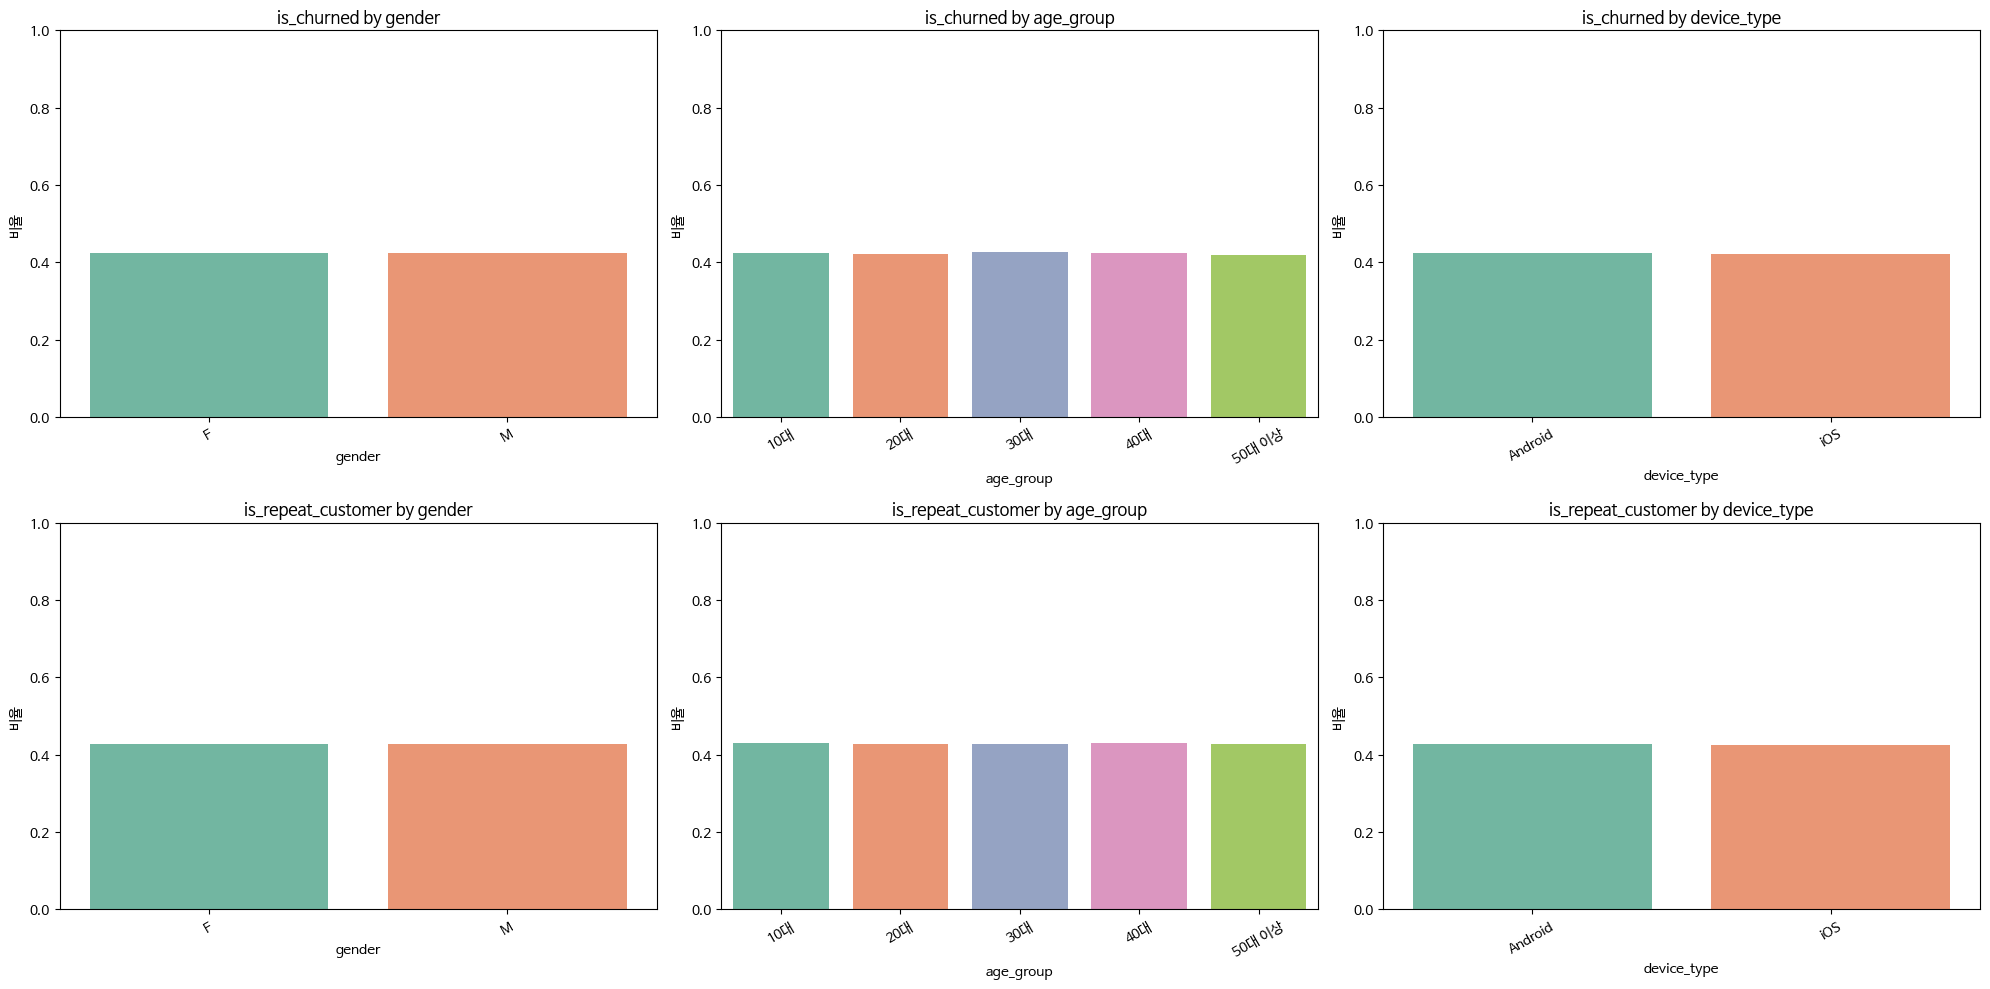

In [6]:
#시각화(Bar chart)
segment_columns = ['gender', 'age_group', 'device_type']
target_metrics = ['is_churned', 'is_repeat_customer']


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

for col_idx, segment in enumerate(segment_columns):
    for row_idx, metric in enumerate(target_metrics):
        ax = axes[row_idx, col_idx]

        # 평균 계산
        plot_data = df_filtered.groupby(segment)[metric].mean().reset_index()

        sns.barplot(
            data=plot_data,
            x=segment,
            y=metric,
            hue=segment,
            dodge=False,
            ax=ax,
            palette='Set2',
            legend=False
            )

        # 타이틀, 라벨 설정
        ax.set_title(f'{metric} by {segment}')
        ax.set_ylabel('비율')
        ax.set_xlabel(segment)
        ax.set_ylim(0, 1)

        for label in ax.get_xticklabels():
            label.set_rotation(30)

plt.tight_layout()
plt.show()


In [7]:
binary_columns = ['gender', 'device_type']
metrics = ['is_churned', 'is_repeat_customer']

print('=== Z-test 결과 ===')
for col in binary_columns:
    for metric in metrics:
        print(run_z_test(df_filtered, col, metric))

print('\n=== Chi-square 검정 결과 ===')
for metric in metrics:
    print(run_chi_square(df_filtered, 'age_group', metric))


=== Z-test 결과 ===
=== gender / is_churned ===
Z-stat:  0.1921, p-value: 0.8476

=== gender / is_repeat_customer ===
Z-stat:  0.5090, p-value: 0.6108

=== device_type / is_churned ===
Z-stat:  0.6723, p-value: 0.5014

=== device_type / is_repeat_customer ===
Z-stat:  0.6308, p-value: 0.5282


=== Chi-square 검정 결과 ===
=== age_group / is_churned ===
Chi²: 1.3922, p-value: 0.8456

=== age_group / is_repeat_customer ===
Chi²: 0.6346, p-value: 0.9591



---

### H2. 가입 시점(cohort)에 따른 리텐션 차이 분석

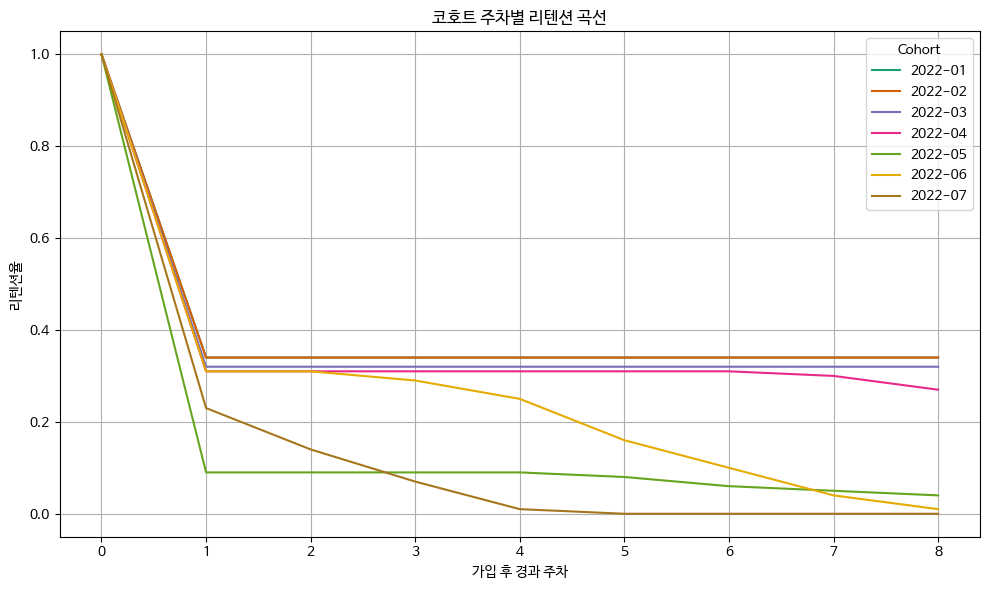

In [8]:
# 2022년 가입자만 필터링
df_filtered = df[df['first_join_date'].dt.year == 2022].copy()


# 가입 후 몇 주까지 활동했는지 계산 (이탈 주차)
df_filtered['weeks_active'] = ((df_filtered['last_order_date'] - df_filtered['first_join_date']).dt.days // 7).fillna(0).astype(int)

# 각 주차별 리텐션 계산을 위한 테이블 구성 함수
def get_retention_by_group(df, group_col, weeks=9, label_map=None):
    records = []

    for value, group_df in df.groupby(group_col):
        label = label_map.get(value, str(value)) if label_map else str(value)
        n_total = group_df['customer_id'].nunique()

        for week in range(weeks):
            retained = group_df[group_df['weeks_active'] >= week]['customer_id'].nunique()
            retention_rate = round(retained / n_total, 2) if n_total > 0 else 0
            records.append({'group': label, 'week': week, 'retention': retention_rate})

    return pd.DataFrame(records)

retention_by_cohort = get_retention_by_group(df_filtered, group_col='cohort_month')

# 시각화(리텐션 곡선 )
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=retention_by_cohort,
    x='week',
    y='retention',
    hue='group',
    palette='Dark2'
)

plt.title('코호트 주차별 리텐션 곡선')
plt.xlabel('가입 후 경과 주차')
plt.ylabel('리텐션율')
plt.legend(title='Cohort')
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# 코호트 리텐션
retention_by_cohort.pivot(index='group', columns='week', values='retention')

week,0,1,2,3,4,5,6,7,8
group,,,,,,,,,
2022-01,1.0,0.34,0.34,0.34,0.34,0.34,0.34,0.34,0.34
2022-02,1.0,0.34,0.34,0.34,0.34,0.34,0.34,0.34,0.34
2022-03,1.0,0.32,0.32,0.32,0.32,0.32,0.32,0.32,0.32
2022-04,1.0,0.31,0.31,0.31,0.31,0.31,0.31,0.30,0.27
2022-05,1.0,0.09,0.09,0.09,0.09,0.08,0.06,0.05,0.04
2022-06,1.0,0.31,0.31,0.29,0.25,0.16,0.10,0.04,0.01
2022-07,1.0,0.23,0.14,0.07,0.01,0.00,0.00,0.00,0.00


---

### H3. 첫 재구매 여부에 따른 장기 리텐션 분석

In [10]:
# 구매한 유저만 대상
df_filtered = df[
    (df['first_join_date'].dt.year == 2022) &
    (df['first_join_date'].dt.month <= 4) &
    (df['has_purchase'] == True)].copy()


# 재구매 여부에 따른 평균 활동 주차 비교
df_filtered.groupby('reordered_within_14d')['weeks_active'].mean().round(0).astype(int)


,weeks_active
reordered_within_14d,
False,10
True,20


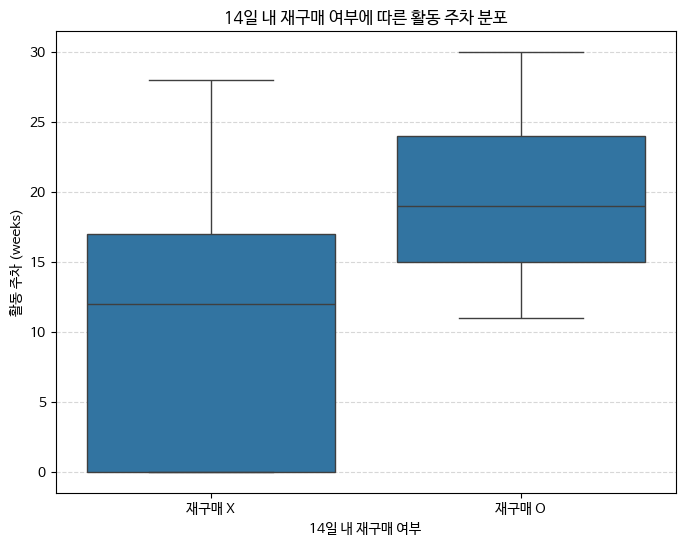

In [11]:
# 시각화(Boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='reordered_within_14d', y='weeks_active', data=df_filtered)
plt.xticks([0, 1], ['재구매 X', '재구매 O'])
plt.title('14일 내 재구매 여부에 따른 활동 주차 분포')
plt.xlabel('14일 내 재구매 여부')
plt.ylabel('활동 주차 (weeks)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


In [12]:
# 리텐션
label_dict = {True: '재구매 O (2주 이내)', False: '재구매 X (2주 이내)'}
retention_df_filtered = get_retention_by_group(df_filtered, group_col='reordered_within_14d', label_map=label_dict)
retention_df_filtered.pivot(index='group', columns='week', values='retention')



week,0,1,2,3,4,5,6,7,8
group,,,,,,,,,
재구매 O (2주 이내),1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
재구매 X (2주 이내),1.0,0.66,0.65,0.65,0.65,0.65,0.65,0.65,0.63


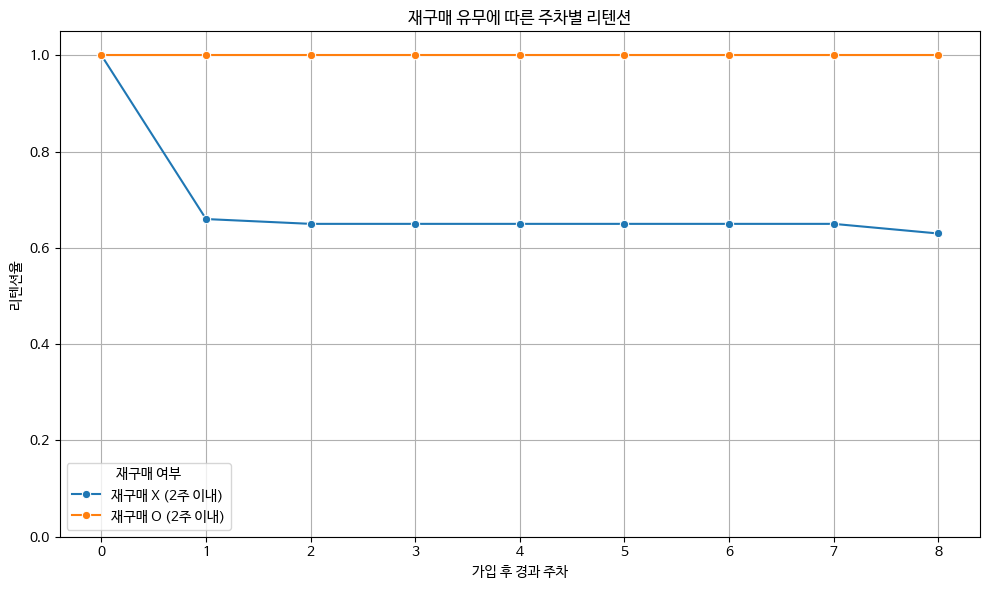

In [13]:
# 시각화(리텐션 곡선)
plt.figure(figsize=(10, 6))
sns.lineplot(data=retention_df_filtered, x='week', y='retention', hue='group', marker='o')

plt.title('재구매 유무에 따른 주차별 리텐션')
plt.xlabel('가입 후 경과 주차')
plt.ylabel('리텐션율')
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend(title='재구매 여부')
plt.tight_layout()
plt.show()



In [14]:
# 재구매 그룹별 유저 수 확인
df_filtered.groupby('reordered_within_14d')['customer_id'].nunique()

,customer_id
reordered_within_14d,
False,2981
True,748


In [15]:
# 그룹별 데이터 분리
weeks_true = df_filtered[df_filtered['reordered_within_14d'] == True]['weeks_active']
weeks_false = df_filtered[df_filtered['reordered_within_14d'] == False]['weeks_active']

# t-test
t_stat, p_val = ttest_ind(weeks_true, weeks_false)
print(f't-test 결과')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_val:.4f}')


t-test 결과
t-statistic: 28.5399
p-value: 0.0000


---

### H4. 누적 구매 횟수에 따른 이탈률 및 이탈 시점 분석


In [16]:
# 구매한 유저 & 2022-05 이전 가입자만 대상
df_filtered = df[(df['first_join_date'] <= pd.to_datetime('2022-04-30')) & (df['has_purchase'] == True)].copy()

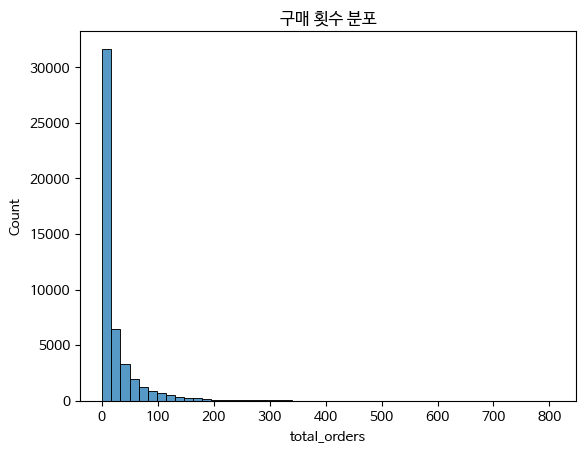

,count
order_group_q,
1Q,12223
4Q,9623
5Q,9560
3Q,9423
2Q,7325


In [17]:
# 분포 확인
sns.histplot(df_filtered['total_orders'], bins=50)
plt.title('구매 횟수 분포')
plt.show()

# 오분위수 기반 그룹
df_filtered['order_group_q'] = pd.qcut(df_filtered['total_orders'], q=5, labels=['1Q', '2Q', '3Q', '4Q', '5Q'])
df_filtered['order_group_q'].value_counts()

In [18]:
pd.qcut(df_filtered['total_orders'], q=5).unique()

[(35.0, 807.0], (13.0, 35.0], (0.999, 2.0], (2.0, 5.0], (5.0, 13.0]]
Categories (5, interval[float64, right]): [(0.999, 2.0] < (2.0, 5.0] < (5.0, 13.0] < (13.0, 35.0] <
                                           (35.0, 807.0]]

In [19]:
# 구간 설정
order_labels = ['1~2회', '3~5회', '6~13회', '14~35회', '36회 이상']
df_filtered['order_group_q'] = pd.qcut(
    df_filtered['total_orders'],
    q=5,
    labels=order_labels
)

In [20]:
# 각 그룹별 이탈률 계산
churn_rate_by_order = df_filtered.groupby('order_group_q')['is_churned'].mean()
print(churn_rate_by_order)

order_group_q
1~2회      0.999918
3~5회      0.983754
6~13회     0.919134
14~35회    0.771693
36회 이상    0.452197
Name: is_churned, dtype: float64


/tmp/ipython-input-20-2361631595.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate_by_order = df_filtered.groupby('order_group_q')['is_churned'].mean()


/tmp/ipython-input-21-3831876819.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped, x='order_group_q', y='is_churned', palette='Blues_d')


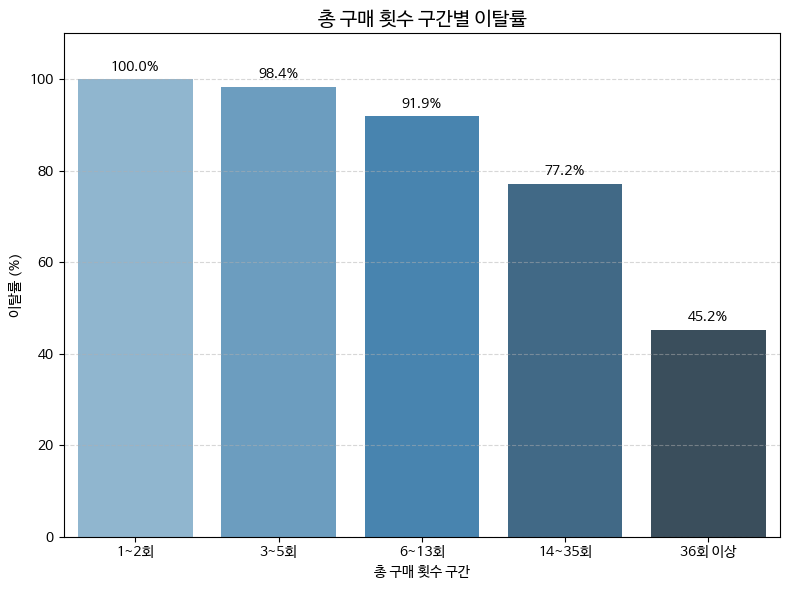

In [21]:
#각 구간별 이탈률 계산
grouped = churn_rate_by_order.reset_index()
grouped['is_churned'] *= 100  # 백분율로 변환

# 이탈률 시각화(Bar chart)
plt.figure(figsize=(8, 6))
sns.barplot(data=grouped, x='order_group_q', y='is_churned', palette='Blues_d')

plt.title('총 구매 횟수 구간별 이탈률', fontsize=14)
plt.xlabel('총 구매 횟수 구간')
plt.ylabel('이탈률 (%)')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 수치 표시
for i, rate in enumerate(grouped['is_churned']):
    plt.text(i, rate + 1, f'{rate:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [22]:
# 카이제곱 검정 수행
print(run_chi_square(df_filtered, 'order_group_q', 'is_churned'))

=== order_group_q / is_churned ===
Chi²: 13983.4967, p-value: 0.0000



In [23]:
# 그룹별 평균 이탈 주차
df_filtered.groupby('order_group_q')['weeks_active'].mean().round(0).astype(int)

/tmp/ipython-input-23-3163813923.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby('order_group_q')['weeks_active'].mean().round(0).astype(int)


,weeks_active
order_group_q,
1~2회,20
3~5회,83
6~13회,110
14~35회,136
36회 이상,176


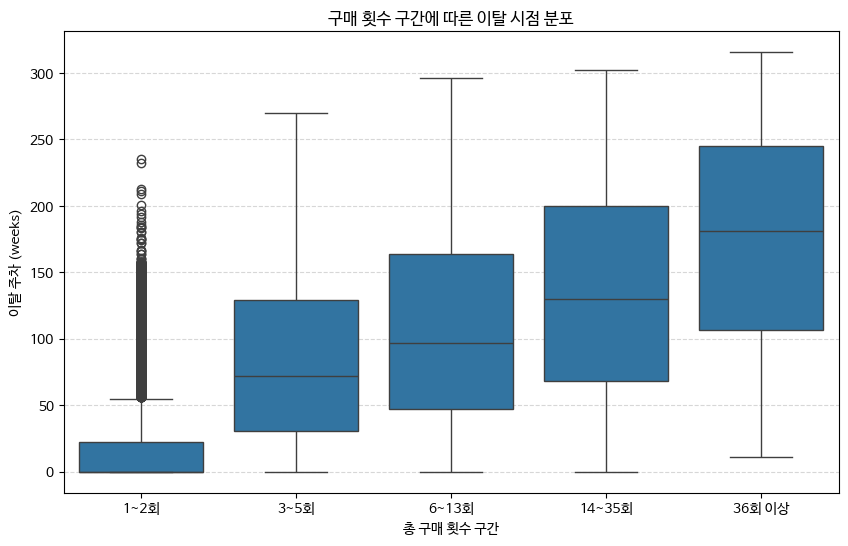

In [24]:
# 이탈 주차 시각화(Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='order_group_q', y='weeks_active', data=df_filtered)
plt.xlabel('총 구매 횟수 구간')
plt.ylabel('이탈 주차 (weeks)')
plt.title('구매 횟수 구간에 따른 이탈 시점 분포')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

---